In [15]:
import math
import time
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import h5py
from scipy.fft import fft, fftfreq
from scipy import interpolate
from itertools import cycle

from readh5 import ResultsFilePopulationMeasurement
from matplotlib.ticker import MaxNLocator



f = mticker.ScalarFormatter(useOffset=False, useMathText=True)
g = lambda x,pos : "${}$".format(f._formatSciNotation('%1.10e' % x))


In [16]:
cvel_ms = 2.99792458e08
hartreeTocm = 219474.63


atu_in_s = 2.41888432650516e-17  # atomic time unit in seconds
cm_in_au = atu_in_s * (2.0*math.pi*1e2*cvel_ms)

# Visualize TD-DRMG Results

In [35]:
""" ---results file --- """
data = ResultsFilePopulationMeasurement('/home/cds/vbarandun/Documents/HolsteinHubbard/20mer/FourthOrder/eicosamerFourthOrder_ts0.1fs_m220_16_06_23/excitonicextended.TD.SS.results_state.0.h5')
#savepath = '/home/cds/nglaser/proj/project_valentin/plotting/plots/eicosamer/'
""" --- select measurements --- """
population = True
autocorr = True
displacement = True
displacementSquared = True

""" --- time axis --- """
finalTime = 7499
t = np.linspace(0, finalTime, finalTime)
tstep = 0.1 #timestep in femtoseconds

""" ---monomers---"""
numMonomers = 20

In [6]:
pop, pop_error = data.extractPopulations()

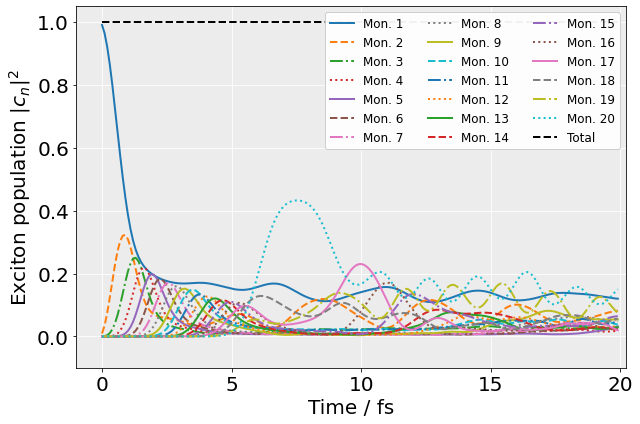

In [30]:
#name = 'eicosamer_pop_20fs'
uplim=200 #upper limit in femtoseconds
fig, ax = plt.subplots(figsize=[9,6])
ax.set_axisbelow(True)
ax.set_facecolor('0.925')
plt.grid(color='w')
num_linestyles=4 #Define the number of unique linestyles you want
# Create a list of linestyles to cycle through.
linestyles = ['-', '--', '-.', ':'][:num_linestyles]
line_cycler = cycle(linestyles)
for i in range(numMonomers):
    linestyle = next(line_cycler)
    label = 'Mon. ' + str(i + 1)
    ax.plot(t[:uplim]*tstep, pop[i, :uplim], linewidth=2, linestyle=linestyle, label=label)
totpop=0
totpop = pop[0,:]
for i in range (1,numMonomers):
    totpop = totpop + pop[i,:]
ax.plot(t[:uplim]*tstep, totpop[:uplim], linewidth=2, color='black', linestyle='dashed', label='Total')
ax.set_ylim(-0.1, 1.05)
ax.set_xlim(-1,20.21)
ax.xaxis.set_major_locator(MaxNLocator(5,integer=True))
ax.set_xlabel('Time / fs', fontsize=20)
ax.set_ylabel('Exciton population ' + r'$|c_n|^2$', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
legend = ax.legend(fontsize=12, ncol=3, loc='upper right', framealpha=0.95)
fig.tight_layout()

#fig.savefig(savepath + name + '.pdf')
plt.show()

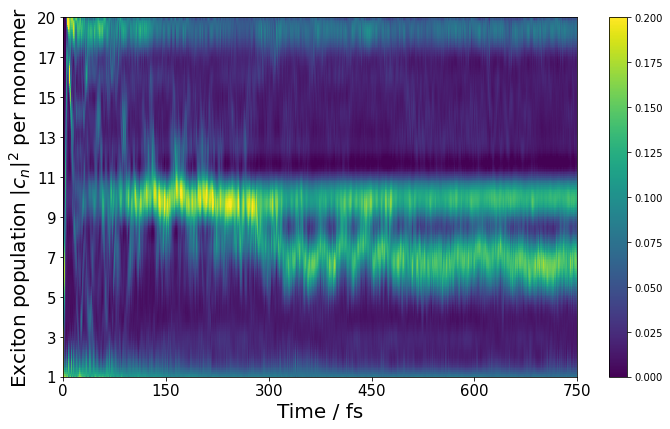

In [31]:
name = 'eicosamer_popmap_full'

""" --- plot poulations --- """
if(population):
    
    timeRange = 750 #timerange in fs that should be plotted 

    populations = [] # Initialize an empty list to store populations
    # Use a loop to create populations from 0 to numMonomers-1
    for i in range(numMonomers):
        populations.append(pop[i,])
    
    TwoDPopulations = np.array(populations, dtype=float)# Use a loop to create populations from 0 to numMonomers-1

    x_points = np.linspace(1,numMonomers,numMonomers)
    x_points_input = np.linspace(1,numMonomers,numMonomers*10)
    TwoDPopulationsInterpolated = np.zeros((len(x_points_input), len(t)), dtype=float)
    for i in range(len(t)):
        y_points = TwoDPopulations[:,i]
        tck = interpolate.splrep(x_points, y_points)
        TwoDPopulationsInterpolated[:,i] = interpolate.splev(x_points_input, tck)

    fig, ax = plt.subplots(figsize=[10,6])
    pcm = ax.pcolormesh( TwoDPopulationsInterpolated , cmap = 'viridis', vmin=0, vmax=0.2)
    ax.set_yticks(np.linspace(0,numMonomers*10,10))
    ax.set_yticklabels(np.linspace(1,numMonomers,10, dtype=int))
    ax.set_xticks(np.linspace(0,finalTime,6))
    ax.set_xticklabels(np.linspace(0,timeRange,6, dtype=int))
    ax.set_xlabel('Time / fs', fontsize=20)
    ax.set_ylabel('Exciton population ' + r'$|c_n|^2$ per monomer', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    fig.colorbar(pcm, ax=ax)
    fig.tight_layout()

    #fig.savefig(savepath + name + '.png', dpi=400)
    plt.show()


In [32]:
input = data.extractAutocorrelation()
autocorrelation = input[:,0] + 1j*input[:,1]

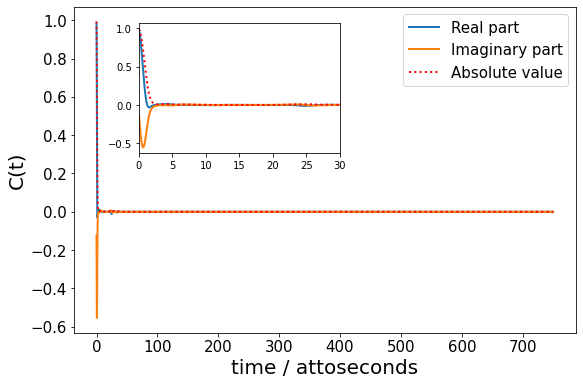

No handles with labels found to put in legend.


795444.2938677


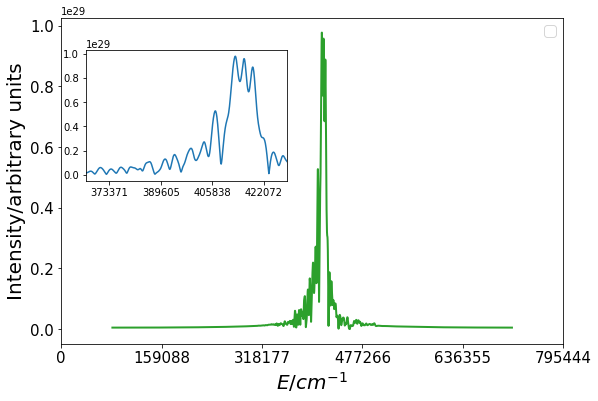

In [33]:
""" --- plot autocorrelation function --- """

fig, ax = plt.subplots(figsize=[9,6])
ax.plot(t*tstep, autocorrelation.real,linewidth=2, label='Real part') 
ax.plot(t*tstep, autocorrelation.imag, linewidth=2, label='Imaginary part')
ax.plot(t*tstep, abs(autocorrelation), linewidth=2, linestyle='dotted', color='red', label='Absolute value')
ax.set_xlabel('time / attoseconds', fontsize=20)
ax.set_ylabel('C(t)', fontsize=20)
ax.tick_params(axis='both', labelsize=15)
legend = ax.legend(fontsize=15)
axIns = ax.inset_axes([0.13, 0.55, 0.4, 0.4])
axIns.plot(t*tstep, autocorrelation.real,linewidth=2) 
axIns.plot(t*tstep, autocorrelation.imag, linewidth=2)
axIns.plot(t*tstep, abs(autocorrelation), linewidth=2, linestyle='dotted', color='red')
axIns.set_xlim(0,30)
plt.show()

#calculating absorption spectrum
tau = 100. #fs
dampingfunc = np.exp(t/tau)
autocorrelation = autocorrelation*dampingfunc
N = len(autocorrelation)
T = len(autocorrelation)*tstep
tFourier = np.linspace(0, T, N)
dt = np.diff(tFourier)[0]
np.pad(autocorrelation, pad_width=(0,len(autocorrelation)))
f = fftfreq(len(tFourier), np.diff(tFourier)[0])
spec = fft(autocorrelation)
spec = np.fft.fftshift(spec)
f = np.fft.fftshift(f)
energyAxis = np.linspace(0,N*106.0733823,6, dtype=int)
print(N*106.0733823)

#plotting spectrum
fig, ax = plt.subplots(figsize=[9,6])
ax.plot(f, np.abs(spec),linewidth=2, color="tab:green")
ax.set_xlabel(r'$E/cm^{-1}$', fontsize=20)  
ax.set_ylabel('Intensity/arbitrary units', fontsize=20)
ax.tick_params(axis='both', labelsize=15)
ax.set_xticks(np.linspace(-2*np.pi,2*np.pi,6))
ax.set_xticklabels(energyAxis)
axIns = ax.inset_axes([0.05, 0.5, 0.4, 0.4])
axIns.plot(f, abs(spec))
axIns.set_xticks(np.linspace(-2*np.pi,2*np.pi,50))
energyAxis = np.linspace(0,N*106.0733823,50, dtype=int)
axIns.set_xticklabels(energyAxis)
axIns.set_xlim(-0.5,0.5)
legend = ax.legend(fontsize=15)
plt.show()

In [67]:
displacement = data.extractDisplacement()

numXMonomers = numMonomers
numYThetaMonomers = numMonomers - 1

displacement_data = {}  # Create a dictionary to store the arrays

# Loop through displacement types (x, y, theta)
for displacement_type in ['displacementx', 'displacementy', 'displacementtheta']:
    for i in range(numMonomers):
        if (displacement_type == 'displacementx'):
            displacement_index = i * 3
            print(displacement_type, displacement_index)
        elif (displacement_type == 'displacementy' and i < numMonomers-1):
            displacement_index = i * 3 + 1
            print(displacement_type, displacement_index)
        elif (displacement_type == 'displacementtheta' and i < numMonomers-1):
            displacement_index = i * 3 + 2
            print(displacement_type, displacement_index)
        if displacement_index < displacement.shape[1]:
            displacement_key = f"{displacement_type}Monomer{i}"
            displacement_data[displacement_key] = displacement[:, displacement_index, 0]

displacementx 0
displacementx 3
displacementx 6
displacementx 9
displacementx 12
displacementx 15
displacementx 18
displacementx 21
displacementx 24
displacementx 27
displacementx 30
displacementx 33
displacementx 36
displacementx 39
displacementx 42
displacementx 45
displacementx 48
displacementx 51
displacementx 54
displacementx 57
displacementy 1
displacementy 4
displacementy 7
displacementy 10
displacementy 13
displacementy 16
displacementy 19
displacementy 22
displacementy 25
displacementy 28
displacementy 31
displacementy 34
displacementy 37
displacementy 40
displacementy 43
displacementy 46
displacementy 49
displacementy 52
displacementy 55
displacementtheta 2
displacementtheta 5
displacementtheta 8
displacementtheta 11
displacementtheta 14
displacementtheta 17
displacementtheta 20
displacementtheta 23
displacementtheta 26
displacementtheta 29
displacementtheta 32
displacementtheta 35
displacementtheta 38
displacementtheta 41
displacementtheta 44
displacementtheta 47
displacemen

In [70]:
print(displacement_data.keys())

dict_keys(['displacementxMonomer0', 'displacementxMonomer1', 'displacementxMonomer2', 'displacementxMonomer3', 'displacementxMonomer4', 'displacementxMonomer5', 'displacementxMonomer6', 'displacementxMonomer7', 'displacementxMonomer8', 'displacementxMonomer9', 'displacementxMonomer10', 'displacementxMonomer11', 'displacementxMonomer12', 'displacementxMonomer13', 'displacementxMonomer14', 'displacementxMonomer15', 'displacementxMonomer16', 'displacementxMonomer17', 'displacementxMonomer18', 'displacementxMonomer19', 'displacementyMonomer0', 'displacementyMonomer1', 'displacementyMonomer2', 'displacementyMonomer3', 'displacementyMonomer4', 'displacementyMonomer5', 'displacementyMonomer6', 'displacementyMonomer7', 'displacementyMonomer8', 'displacementyMonomer9', 'displacementyMonomer10', 'displacementyMonomer11', 'displacementyMonomer12', 'displacementyMonomer13', 'displacementyMonomer14', 'displacementyMonomer15', 'displacementyMonomer16', 'displacementyMonomer17', 'displacementyMonomer

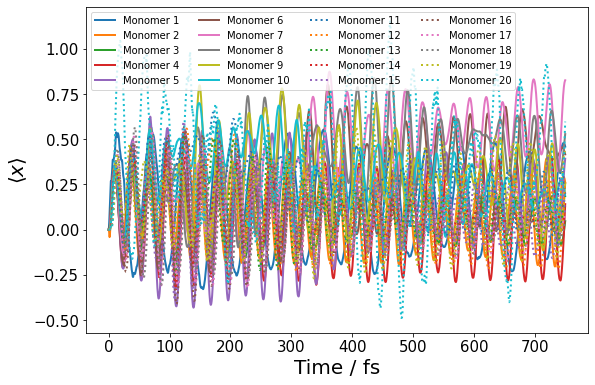

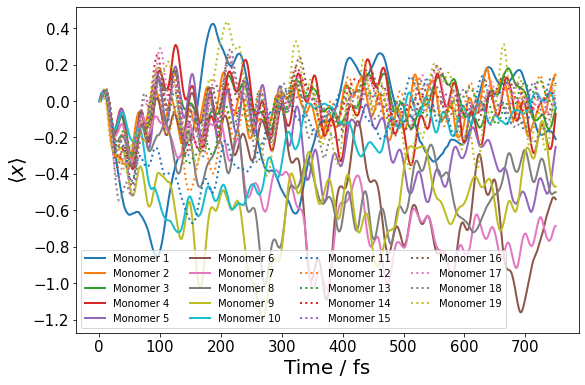

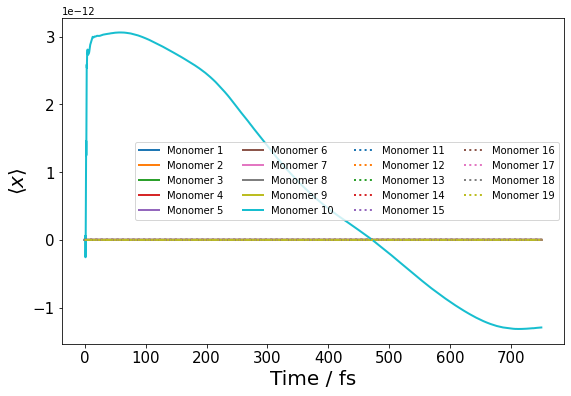

In [72]:
fig, ax = plt.subplots(figsize=[9, 6])
ax.set_xlabel('Time / fs', fontsize=20)
ax.set_ylabel(r'$\langle x \rangle$', fontsize=20)
ax.tick_params(axis='both', labelsize=15)

#plot x displacement
for i in range(numMonomers):
    displacement_key = f"displacementxMonomer{i}"
    label = f'Monomer {i + 1}'
    linestyle = 'dotted' if i >= 10 else 'solid'
    
    ax.plot(t * tstep, displacement_data[displacement_key], linewidth=2, label=label, linestyle=linestyle)

legend = ax.legend(fontsize=10, ncol=4)
plt.show()

#plot y displacement
fig, ax = plt.subplots(figsize=[9, 6])
ax.set_xlabel('Time / fs', fontsize=20)
ax.set_ylabel(r'$\langle x \rangle$', fontsize=20)
ax.tick_params(axis='both', labelsize=15)

for i in range(numMonomers-1):
    displacement_key = f"displacementyMonomer{i}"
    label = f'Monomer {i + 1}'
    linestyle = 'dotted' if i >= 10 else 'solid'
    
    ax.plot(t * tstep, displacement_data[displacement_key], linewidth=2, label=label, linestyle=linestyle)

legend = ax.legend(fontsize=10, ncol=4)
plt.show()

#plot theta displacement
fig, ax = plt.subplots(figsize=[9, 6])
ax.set_xlabel('Time / fs', fontsize=20)
ax.set_ylabel(r'$\langle x \rangle$', fontsize=20)
ax.tick_params(axis='both', labelsize=15)

for i in range(numMonomers-1):
    displacement_key = f"displacementthetaMonomer{i}"
    label = f'Monomer {i + 1}'
    linestyle = 'dotted' if i >= 10 else 'solid'
    
    ax.plot(t * tstep, displacement_data[displacement_key], linewidth=2, label=label, linestyle=linestyle)

legend = ax.legend(fontsize=10, ncol=4)
plt.show()



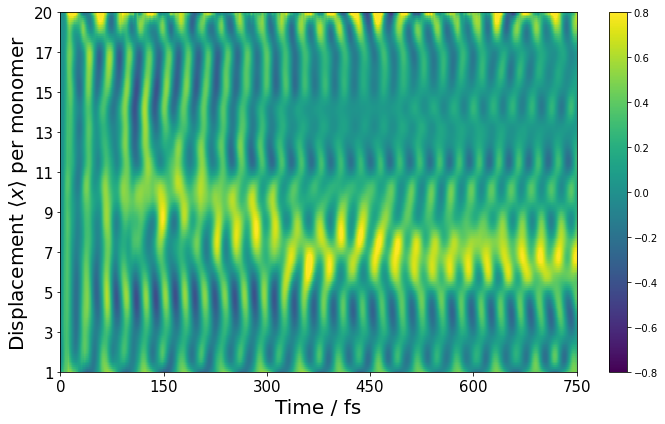

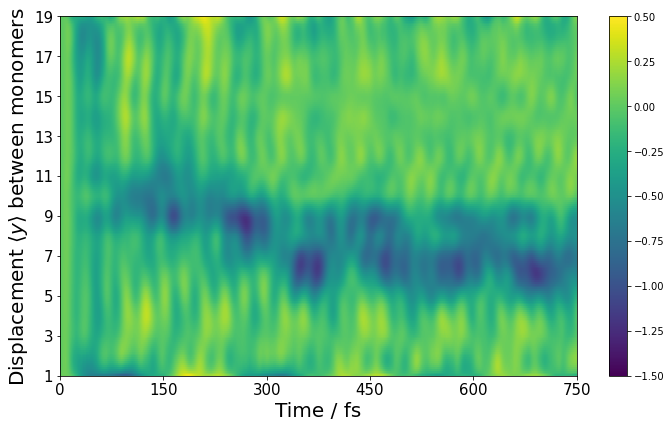

In [80]:
""" --- plot displacement --- """

numXMonomers = numMonomers

# Create an empty list to store the x-displacement arrays
x_displacement_arrays = []

# Loop through the x-displacement keys
for i in range(numXMonomers):
    displacement_key = f"displacementxMonomer{i}"
    
    # Check if the key exists in the dictionary
    if displacement_key in displacement_data:
        x_displacement_array = displacement_data[displacement_key]
        x_displacement_arrays.append(x_displacement_array)

# Convert the list of arrays to a numpy array
TwoDxDisplacement = np.array(x_displacement_arrays, dtype=float)

x_points = np.linspace(0,19,20)
x_points_input = np.linspace(0,19,200)
TwoDxDisplacementInterpolated = np.zeros((len(x_points_input), len(t)), dtype=float)
for i in range(len(t)):
    y_points = TwoDxDisplacement[:,i]
    tck = interpolate.splrep(x_points, y_points)
    TwoDxDisplacementInterpolated[:,i] = interpolate.splev(x_points_input, tck)

name = 'eicosamer_xdispmap'
fig, ax = plt.subplots(figsize=[10,6])
pcm = ax.pcolormesh( TwoDxDisplacementInterpolated , cmap = 'viridis', vmin=-0.8, vmax=0.8)
ax.set_yticks(np.linspace(0,200,10))
ax.set_yticklabels(np.linspace(1,20,10, dtype=int))
ax.set_xticks(np.linspace(0,7499,6))
ax.set_xticklabels(np.linspace(0,750,6, dtype=int))
ax.set_xlabel('Time / fs', fontsize=20)
ax.set_ylabel('Displacement ' + r'$\langle x \rangle$ per monomer', fontsize=20)
ax.tick_params(axis='both', labelsize=15)
fig.colorbar(pcm, ax=ax)
fig.tight_layout()
#fig.savefig(savepath + name + '.png', dpi=400)
plt.show()



# Assuming you have defined displacement_data and numMonomers
numXMonomers = numMonomers

# Create an empty list to store the x-displacement arrays
y_displacement_arrays = []

# Loop through the x-displacement keys
for i in range(numXMonomers-1):
    displacement_key = f"displacementyMonomer{i}"
    
    # Check if the key exists in the dictionary
    if displacement_key in displacement_data:
        y_displacement_array = displacement_data[displacement_key]
        y_displacement_arrays.append(y_displacement_array)

# Convert the list of arrays to a numpy array
TwoDyDisplacement = np.array(y_displacement_arrays, dtype=float)


x_points = np.linspace(0,18,19)
x_points_input = np.linspace(0,18,190)
TwoDyDisplacementInterpolated = np.zeros((len(x_points_input), len(t)), dtype=float)
for i in range(len(t)):
    y_points = TwoDyDisplacement[:,i]
    tck = interpolate.splrep(x_points, y_points)
    TwoDyDisplacementInterpolated[:,i] = interpolate.splev(x_points_input, tck)


name = 'eicosamer_ydispmap'

fig, ax = plt.subplots(figsize=[10,6])
pcm = ax.pcolormesh( TwoDyDisplacementInterpolated , cmap = 'viridis', vmin=-1.5, vmax=0.5)
ax.set_yticks(np.linspace(0,190,10))
ax.set_yticklabels(np.linspace(1,19,10, dtype=int))
ax.set_xticks(np.linspace(0,7499,6))
ax.set_xticklabels(np.linspace(0,750,6, dtype=int))
ax.set_ylabel('Displacement ' + r'$\langle y \rangle$ between monomers', fontsize=20)
ax.set_xlabel('Time / fs', fontsize=20)
ax.tick_params(axis='both', labelsize=15)
fig.colorbar(pcm, ax=ax)
fig.tight_layout()
#fig.savefig(savepath + name + '.png', dpi=400)
plt.show()


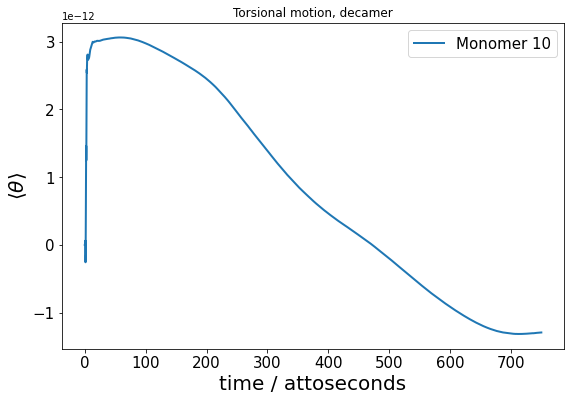

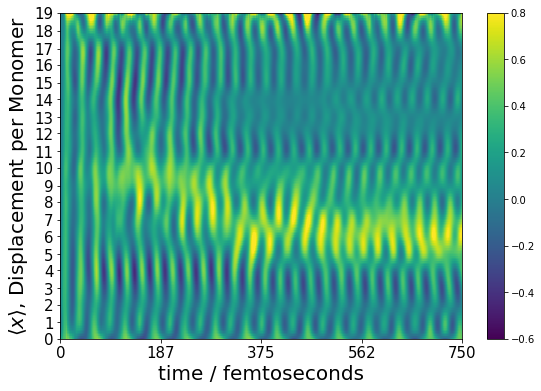

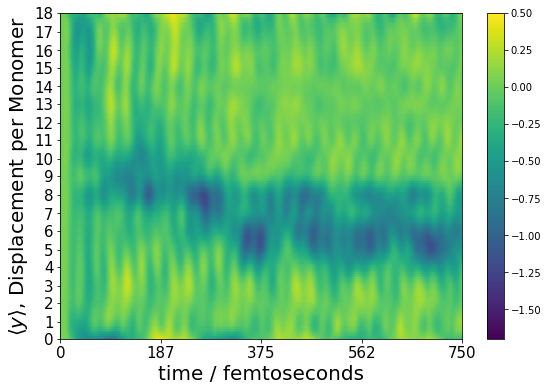

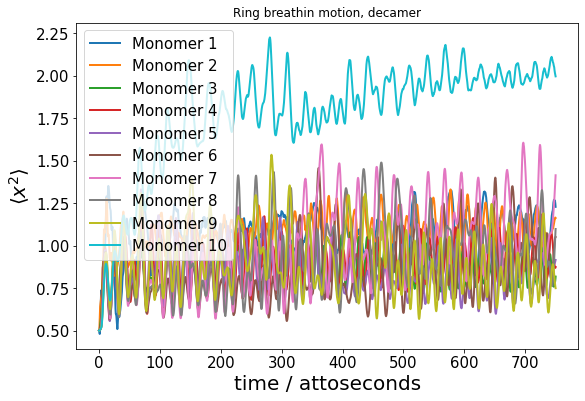

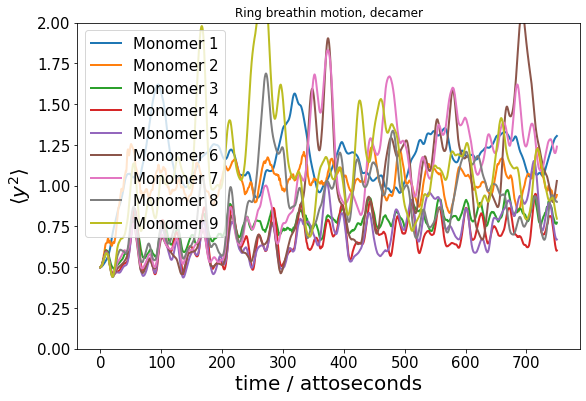

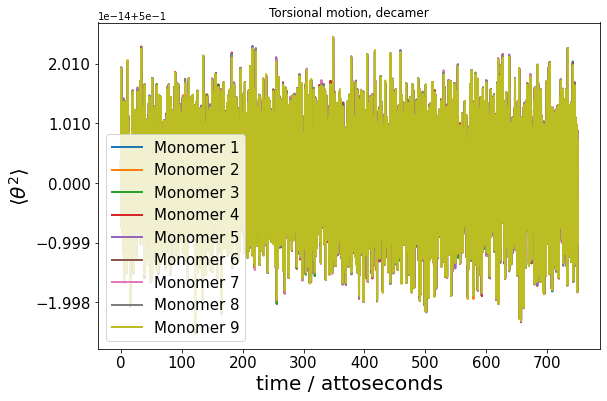

In [55]:

""" --- plot squared displacement --- """
if(displacementSquared):
    
    displacementSquared = data.extractDisplacementSquared()

    numXMonomers = numMonomers
    numYThetaMonomers = numMonomers - 1

    displacementSquared_data = {}  # Create a dictionary to store the arrays

    # Loop through displacement types (x, y, theta)
    for displacementSquared_type in ['displacementSquaredx', 'displacementSquaredy', 'displacementSquaredtheta']:
        for i in range(numMonomers):
            if (displacementSquared_type == 'displacementSquaredx'):
                displacementSquared_index = i * 3
                print(displacementSquared_type, displacementSquared_index)
            elif (displacementSquared_type == 'displacementSquaredy' and i < numMonomers-1):
                displacementSquared_index = i * 3 + 1
                print(displacementSquared_type, displacementSquared_index)
            elif (displacementSquared_type == 'displacementSquaredtheta' and i < numMonomers-1):
                displacementSquared_index = i * 3 + 2
                print(displacementSquared_type, displacementSquared_index)
            if displacementSquared_index < displacementSquared.shape[1]:
                displacementSquared_key = f"{displacementSquared_type}Monomer{i}"
                displacementSquared_data[displacementSquared_key] = displacementSquared[:, displacementSquared_index, 0]
    

    #plot x displacement    
    fig, ax = plt.subplots(figsize=[9, 6])
    ax.set_xlabel('Time / fs', fontsize=20)
    ax.set_ylabel(r'$\langle x \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)

    for i in range(numMonomers):
        displacementSquared_key = f"displacementSquaredxMonomer{i}"
        label = f'Monomer {i + 1}'
        linestyle = 'dotted' if i >= 10 else 'solid'
        ax.plot(t * tstep, displacementSquared_data[displacementSquared_key], linewidth=2, label=label, linestyle=linestyle)

    legend = ax.legend(fontsize=10, ncol=4)
    plt.show()


    #plot y displacement
    fig, ax = plt.subplots(figsize=[9, 6])
    ax.set_xlabel('Time / fs', fontsize=20)
    ax.set_ylabel(r'$\langle x \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    
    for i in range(numMonomers-1):
        displacementSquared_key = f"displacementSquaredyMonomer{i}"
        label = f'Monomer {i + 1}'
        linestyle = 'dotted' if i >= 10 else 'solid'
        ax.plot(t * tstep, displacementSquared_data[displacementSquared_key], linewidth=2, label=label, linestyle=linestyle)
    
    legend = ax.legend(fontsize=10, ncol=4)
    plt.show()



    #plotting y-mode
    fig, ax = plt.subplots(figsize=[9,6])
    ax.set_title('Ring breathin motion, decamer')
    ax.plot(t*tstep, displacementSquaredyMonomer0,linewidth=2, label = 'Monomer 1')
    ax.plot(t*tstep, displacementSquaredyMonomer1,linewidth=2, label = 'Monomer 2')
    ax.plot(t*tstep, displacementSquaredyMonomer2,linewidth=2, label = 'Monomer 3')
    ax.plot(t*tstep, displacementSquaredyMonomer3,linewidth=2, label = 'Monomer 4')
    ax.plot(t*tstep, displacementSquaredyMonomer4,linewidth=2, label = 'Monomer 5')
    ax.plot(t*tstep, displacementSquaredyMonomer5,linewidth=2, label = 'Monomer 6')
    ax.plot(t*tstep, displacementSquaredyMonomer6,linewidth=2, label = 'Monomer 7')
    ax.plot(t*tstep, displacementSquaredyMonomer7,linewidth=2, label = 'Monomer 8')
    ax.plot(t*tstep, displacementSquaredyMonomer8,linewidth=2, label = 'Monomer 9')
    ax.set_ylim(0,2)
    ax.set_xlabel('time / attoseconds', fontsize=20)  
    ax.set_ylabel(r'$\langle y^2 \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    legend = ax.legend(fontsize=15)
    plt.show()

    #plotting theta-mode
    fig, ax = plt.subplots(figsize=[9,6])
    ax.set_title('Torsional motion, decamer')
    ax.plot(t*tstep, displacementSquaredthetaMonomer0,linewidth=2, label = 'Monomer 1')
    ax.plot(t*tstep, displacementSquaredthetaMonomer1,linewidth=2, label = 'Monomer 2')
    ax.plot(t*tstep, displacementSquaredthetaMonomer2,linewidth=2, label = 'Monomer 3')
    ax.plot(t*tstep, displacementSquaredthetaMonomer3,linewidth=2, label = 'Monomer 4')
    ax.plot(t*tstep, displacementSquaredthetaMonomer4,linewidth=2, label = 'Monomer 5')
    ax.plot(t*tstep, displacementSquaredthetaMonomer5,linewidth=2, label = 'Monomer 6')
    ax.plot(t*tstep, displacementSquaredthetaMonomer6,linewidth=2, label = 'Monomer 7')
    ax.plot(t*tstep, displacementSquaredthetaMonomer7,linewidth=2, label = 'Monomer 8')
    ax.plot(t*tstep, displacementSquaredthetaMonomer8,linewidth=2, label = 'Monomer 9')
    ax.set_xlabel('time / attoseconds', fontsize=20)  
    ax.set_ylabel(r'$\langle \theta^2 \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    legend = ax.legend(fontsize=15)
    plt.show()
    


